In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("houses_simple.csv")
df.head()
df1=df.copy()[['area_sqm','price_k']]
df1.columns=['area','price']


梯度下降法的步骤\
1.定义loss函数\
2.确定loss函数基本性质\
3.计算各个变量偏导，计算梯度，\
4.设置步长迭代次数\
5.更新参数，迭代生成结果

\begin{flalign*}
\frac{\partial J}{\partial w} &=\frac{1}{m}\sum_{i=1}^{m}(y_{pred}^{(i)}-y^{(i)})x^{(i)}&\\
\frac{\partial J}{\partial b} &=\frac{1}{m}\sum_{i=1}^{m}(y_{pred}^{(i)}-y^{(i)})&
\end{flalign*}


### 代码实现

最终回归方程: y = 3.8135 * x + -29.9805
最终 Cost (带1/2): 2619.8222


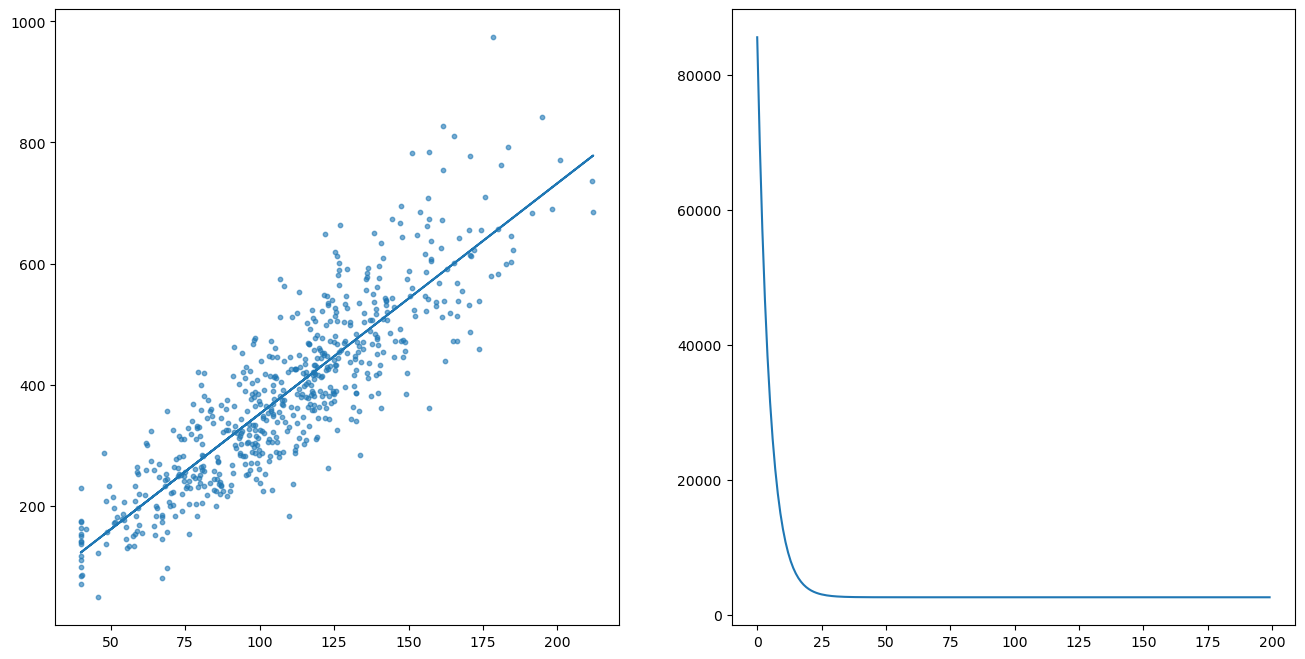

In [29]:
#数据处理-标准化
X=df1['area'].values
y=df1['price'].values

X_mean=X.mean()
X_std=X.std()
X_norm=(X-X_mean)/X_std

#设置参数
w=0.0
b=0.0
learning_rate=0.1
epochs=200
n=len(y)

cost_history=[]
#开始迭代
for i in range(epochs):
    y_pred=w*X_norm+b
    #loss函数
    cost=(1/(2*n))*np.sum((y_pred-y)**2)
    cost_history.append(cost)
    #计算梯度
    dw=(1/n)*np.sum((y_pred-y)*X_norm)
    db=(1/n)*np.sum(y_pred-y)
    #更新参数
    w=w-learning_rate*dw
    b=b-learning_rate*db

w_orig=w/X_std
b_orig=b-w_orig*X_mean

print(f"最终回归方程: y = {w_orig:.4f} * x + {b_orig:.4f}")
print(f"最终 Cost (带1/2): {cost_history[-1]:.4f}")


# 6. 可视化
fig,axes=plt.subplots(1,2,figsize=(16,8))
ax1=axes[0]
ax2=axes[1]
ax1.scatter(X,y,s=10,alpha=0.6)
ax1.plot(X,w_orig*X+b_orig)
ax2.plot(range(epochs),cost_history)

